# Análise de Dados de Energia Eólica — Kaggle Dataset

## Objetivo
Este notebook analisa dados meteorológicos e de geração eólica de quatro localizações durante o ano de 2017.

## Fonte dos Dados
- **Plataforma:** Kaggle — Wind Power Forecasting Dataset
- **Período:** 2017 (dados horários)
- **Localizações:** Location1, Location2, Location3, Location4

## Variáveis Disponíveis
| Variável | Unidade | Descrição |
|---|---|---|
| `windspeed_100m` | m/s | Velocidade do vento a 100m (altura de hub) |
| `winddirection_100m` | ° | Direção do vento a 100m |
| `windgusts_10m` | m/s | Rajadas de vento a 10m |
| `temperature_2m` | °F / °C | Temperatura a 2m de altura |
| `relativehumidity_2m` | % | Umidade relativa a 2m |
| `Power` | — | Potência normalizada (0 a 1, sem valor nominal conhecido por localização) |

> **Nota sobre potência normalizada:** O dataset Kaggle fornece `Power` como valor adimensional entre 0 e 1.
> Não há informação do valor nominal em kW de cada turbina, por isso trabalhamos com a escala normalizada.
> Isso é uma limitação real do dataset — a magnitude absoluta de geração não pode ser estimada sem metadados adicionais.


## Detecção de Anomalias com DBSCAN

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) é um algoritmo de clustering 
que identifica pontos em regiões de alta densidade como clusters e pontos isolados como **anomalias (ruído)**.

### Parâmetros
| Parâmetro | Valor | Significado |
|---|---|---|
| `eps` | 0.3 | Raio máximo de vizinhança (em escala normalizada) |
| `min_samples` | 10 | Mínimo de vizinhos para formar um cluster |

### Interpretação Física
- **Cluster principal (label ≥ 0):** Operação normal — pontos seguindo a curva de potência esperada.
- **Ruído (label = -1):** Anomalias — valores fora da densidade normal, indicando:
  - Falhas de equipamento
  - Paradas não planejadas
  - Erros de medição SCADA
  - Operação em condições atípicas (rajadas, gelo, etc.)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline


In [3]:
df1 = pd.read_csv('Location1.csv', sep=',')
df2 = pd.read_csv('Location2.csv', sep=',')
df3 = pd.read_csv('Location3.csv', sep=',')
df4 = pd.read_csv('Location4.csv', sep=',')

df1['Location'] = 'Location1'
df2['Location'] = 'Location2'
df3['Location'] = 'Location3'
df4['Location'] = 'Location4'

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
df.head()


Shape: (175200, 11)

Dtypes:
Time                    object
temperature_2m         float64
relativehumidity_2m      int64
dewpoint_2m            float64
windspeed_10m          float64
windspeed_100m         float64
winddirection_10m        int64
winddirection_100m       int64
windgusts_10m          float64
Power                  float64
Location                object
dtype: object

Valores nulos:
Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
Location               0
dtype: int64


,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,Location1
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,Location1
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,Location1
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,Location1
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,Location1


## Estatísticas Descritivas — Interpretação para Turbinas Eólicas

O método `describe()` revela características importantes do regime de vento e geração:

- **`windspeed_100m`** (m/s): A altura de 100m corresponde à altura de hub típica de turbinas modernas. 
  A média e o percentil 50 indicam o vento característico do local. Alta variância sugere recurso eólico variável.
- **`Power`** (normalizada): Valores próximos de 0.5 indicam operação razoável. Zeros frequentes sugerem cortes ou períodos de baixo vento.
- **`relativehumidity_2m`** (%): Alta umidade pode indicar névoa ou chuva, afetando sensores SCADA.
- **`windgusts_10m`** (m/s): Rajadas próximas ao cut-out (≈25 m/s) acionam parada de emergência da turbina.


In [4]:
# Conversão Fahrenheit → Celsius: C = (F - 32) * 5/9
df['temperature_2m'] = (df['temperature_2m'] - 32) * 5 / 9
df['dewpoint_2m'] = (df['dewpoint_2m'] - 32) * 5 / 9

print("Conversão F → C aplicada nas colunas temperature_2m e dewpoint_2m.\n")
df[['temperature_2m', 'dewpoint_2m']].describe()


Conversão F → C aplicada nas colunas temperature_2m e dewpoint_2m.



,temperature_2m,dewpoint_2m
count,175200.000000,175200.000000
mean,8.142219,2.509023
std,12.229299,11.629530
min,-35.111111,-37.888889
25%,-1.000000,-5.611111
50%,8.277778,2.333333
75%,18.500000,12.555556
max,38.722222,25.944444


In [5]:
desc = df.describe().T
desc


,count,mean,std,min,25%,50%,75%,max
temperature_2m,175200.0,8.142219,12.229299,-35.111111,-1.000000,8.277778,18.500000,38.722222
relativehumidity_2m,175200.0,70.155291,17.326678,9.000000,57.000000,72.000000,84.000000,100.000000
dewpoint_2m,175200.0,2.509023,11.629530,-37.888889,-5.611111,2.333333,12.555556,25.944444
windspeed_10m,175200.0,4.157639,2.012682,0.000000,2.630000,3.850000,5.380000,18.530000
windspeed_100m,175200.0,6.879334,3.043964,0.000000,4.700000,6.680000,8.800000,24.590000
winddirection_10m,175200.0,201.589446,99.639040,1.000000,130.000000,211.000000,288.000000,360.000000
winddirection_100m,175200.0,201.539070,100.683777,0.000000,129.000000,211.000000,290.000000,360.000000
windgusts_10m,175200.0,8.038205,3.617488,0.500000,5.300000,7.600000,10.300000,29.200000
Power,175200.0,0.303429,0.257325,0.000000,0.087700,0.233100,0.474200,0.999400


A tabela `describe()` resume, para cada variável numérica: contagem (count), média (mean), desvio padrão (std), mínimo, quartis (25%, 50%, 75%) e máximo.

**Informações obtidas:**
- **Escala e magnitude:** Permite comparar a ordem de grandeza de cada variável e identificar a necessidade de normalização/padronização para modelos que são sensíveis à escala (ex: redes neurais, KNN).
- **Valores extremos:** Mínimos e máximos fora do esperado podem sinalizar erros de sensor ou condições atípicas. Por exemplo, velocidade negativa do vento ou umidade acima de 100% indicariam problemas de qualidade dos dados.
- **Variabilidade:** O desvio padrão e o intervalo interquartil (Q3 − Q1) revelam o quão dispersos são os dados. Variáveis com alta variabilidade tendem a ser mais informativas para modelos preditivos.
- **Verificação de consistência:** Após a conversão F→C, é possível confirmar se os valores de temperatura e ponto de orvalho estão em faixas plausíveis para o local estudado.

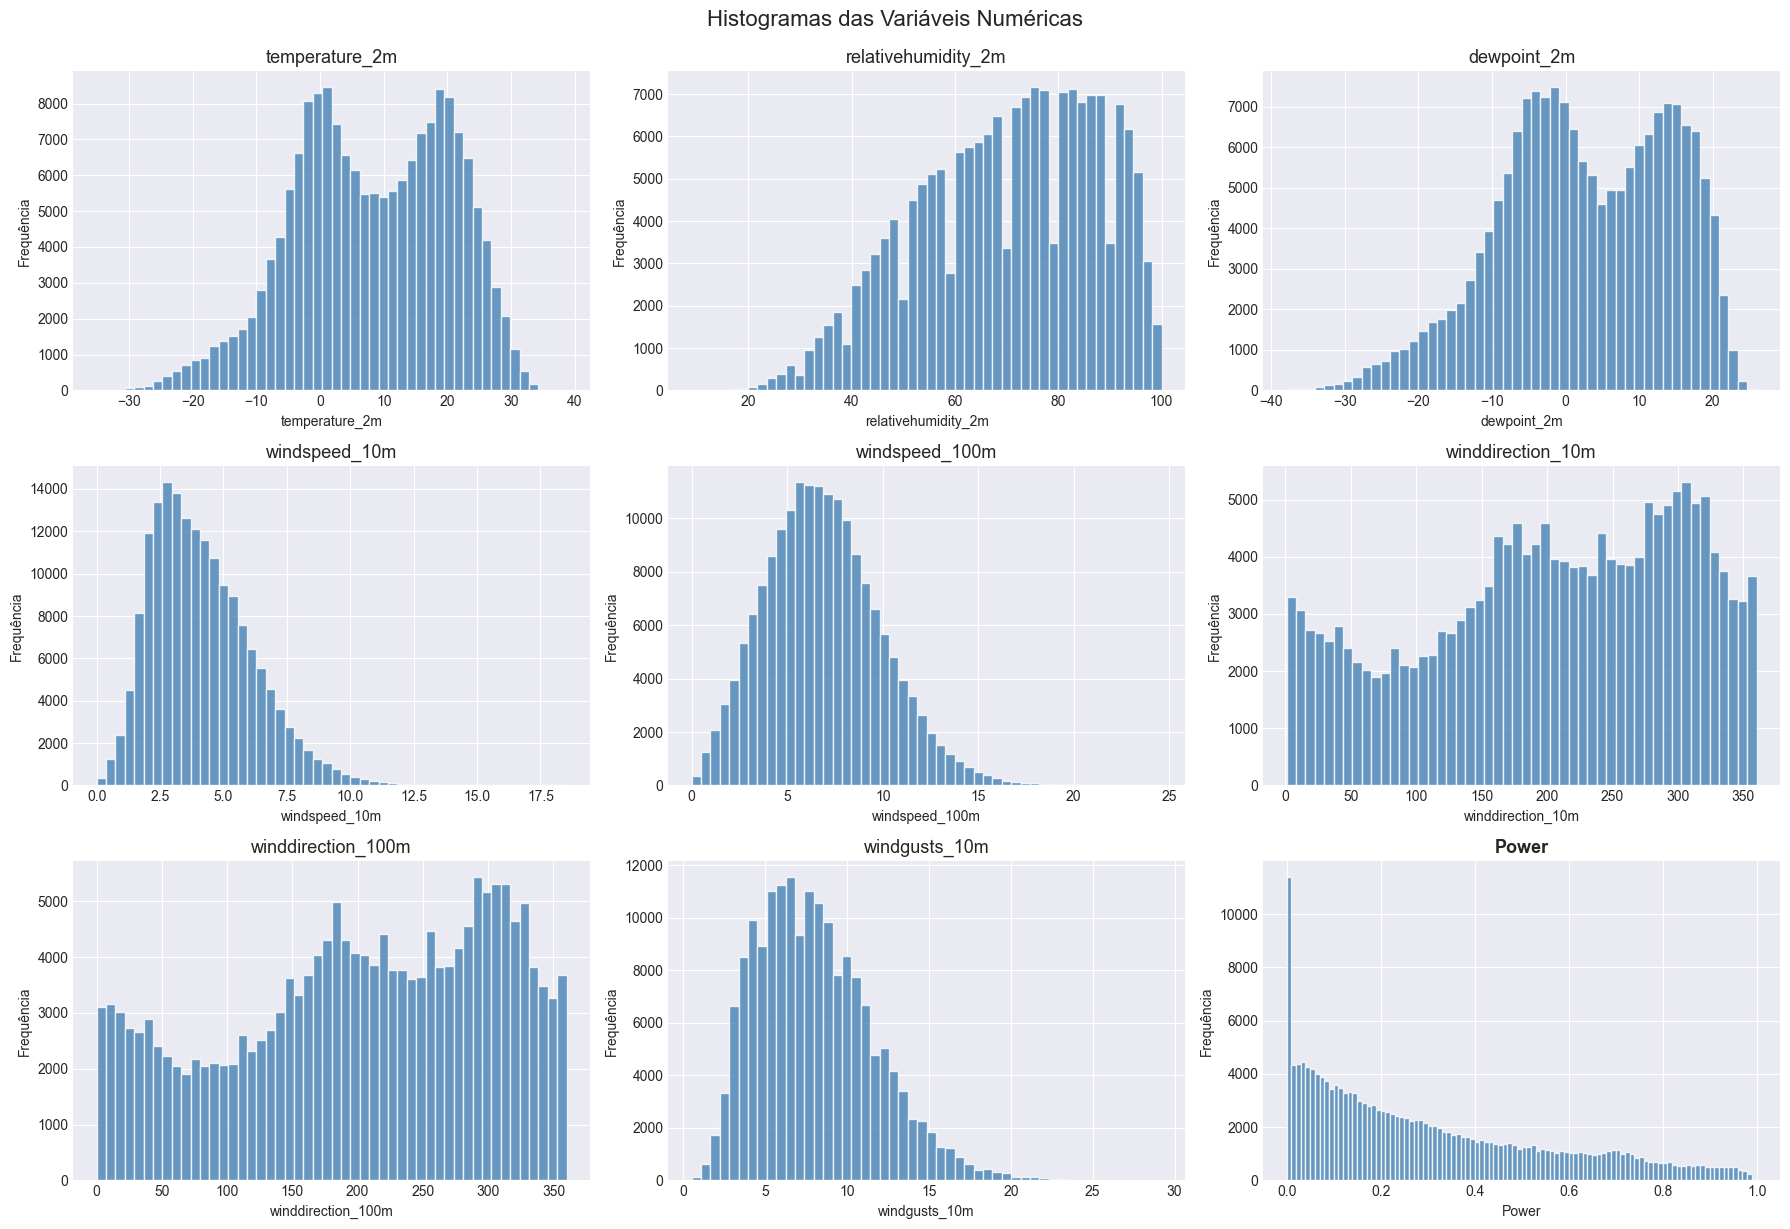

In [6]:
num_cols = ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
            'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
            'winddirection_100m', 'windgusts_10m', 'Power']

n_cols_grid = 3
n_rows_grid = int(np.ceil(len(num_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    bins = 100 if col == 'Power' else 50
    ax.hist(df[col].dropna(), bins=bins, edgecolor='white', color='steelblue', alpha=0.8)
    ax.set_title(col, fontsize=13, fontweight='bold' if col == 'Power' else 'normal')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequência')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Histogramas das Variáveis Numéricas', fontsize=16, y=1.02)
plt.show()


**Informações obtidas:**
- **Distribuição da velocidade do vento (`windspeed_10m`, `windspeed_100m`):** Em sites eólicos, a velocidade do vento tipicamente segue uma distribuição de Weibull. O histograma permite verificar visualmente se essa premissa é razoável e estimar os parâmetros de forma (k) e escala (A), fundamentais para o cálculo da produção anual de energia (AEP).
- **Distribuição da potência (`Power`):** Espera-se uma distribuição bimodal — muitas observações próximas de 0 (vento abaixo do cut-in) e um pico na potência nominal. Se não apresentar esse padrão, pode indicar curtailment frequente ou problemas de disponibilidade.
- **Variáveis meteorológicas:** A forma da distribuição de temperatura, umidade e ponto de orvalho indica o clima típico do local e ajuda a identificar se há valores extremos anômalos.
- **Rajadas (`windgusts_10m`):** A cauda direita do histograma revela a frequência de eventos extremos — informação crítica para análises de carga estrutural das turbinas.
- **Direção do vento (`winddirection`):** Distribuição uniforme indica ventos sem direção preferencial; picos concentrados revelam uma ou mais direções dominantes.

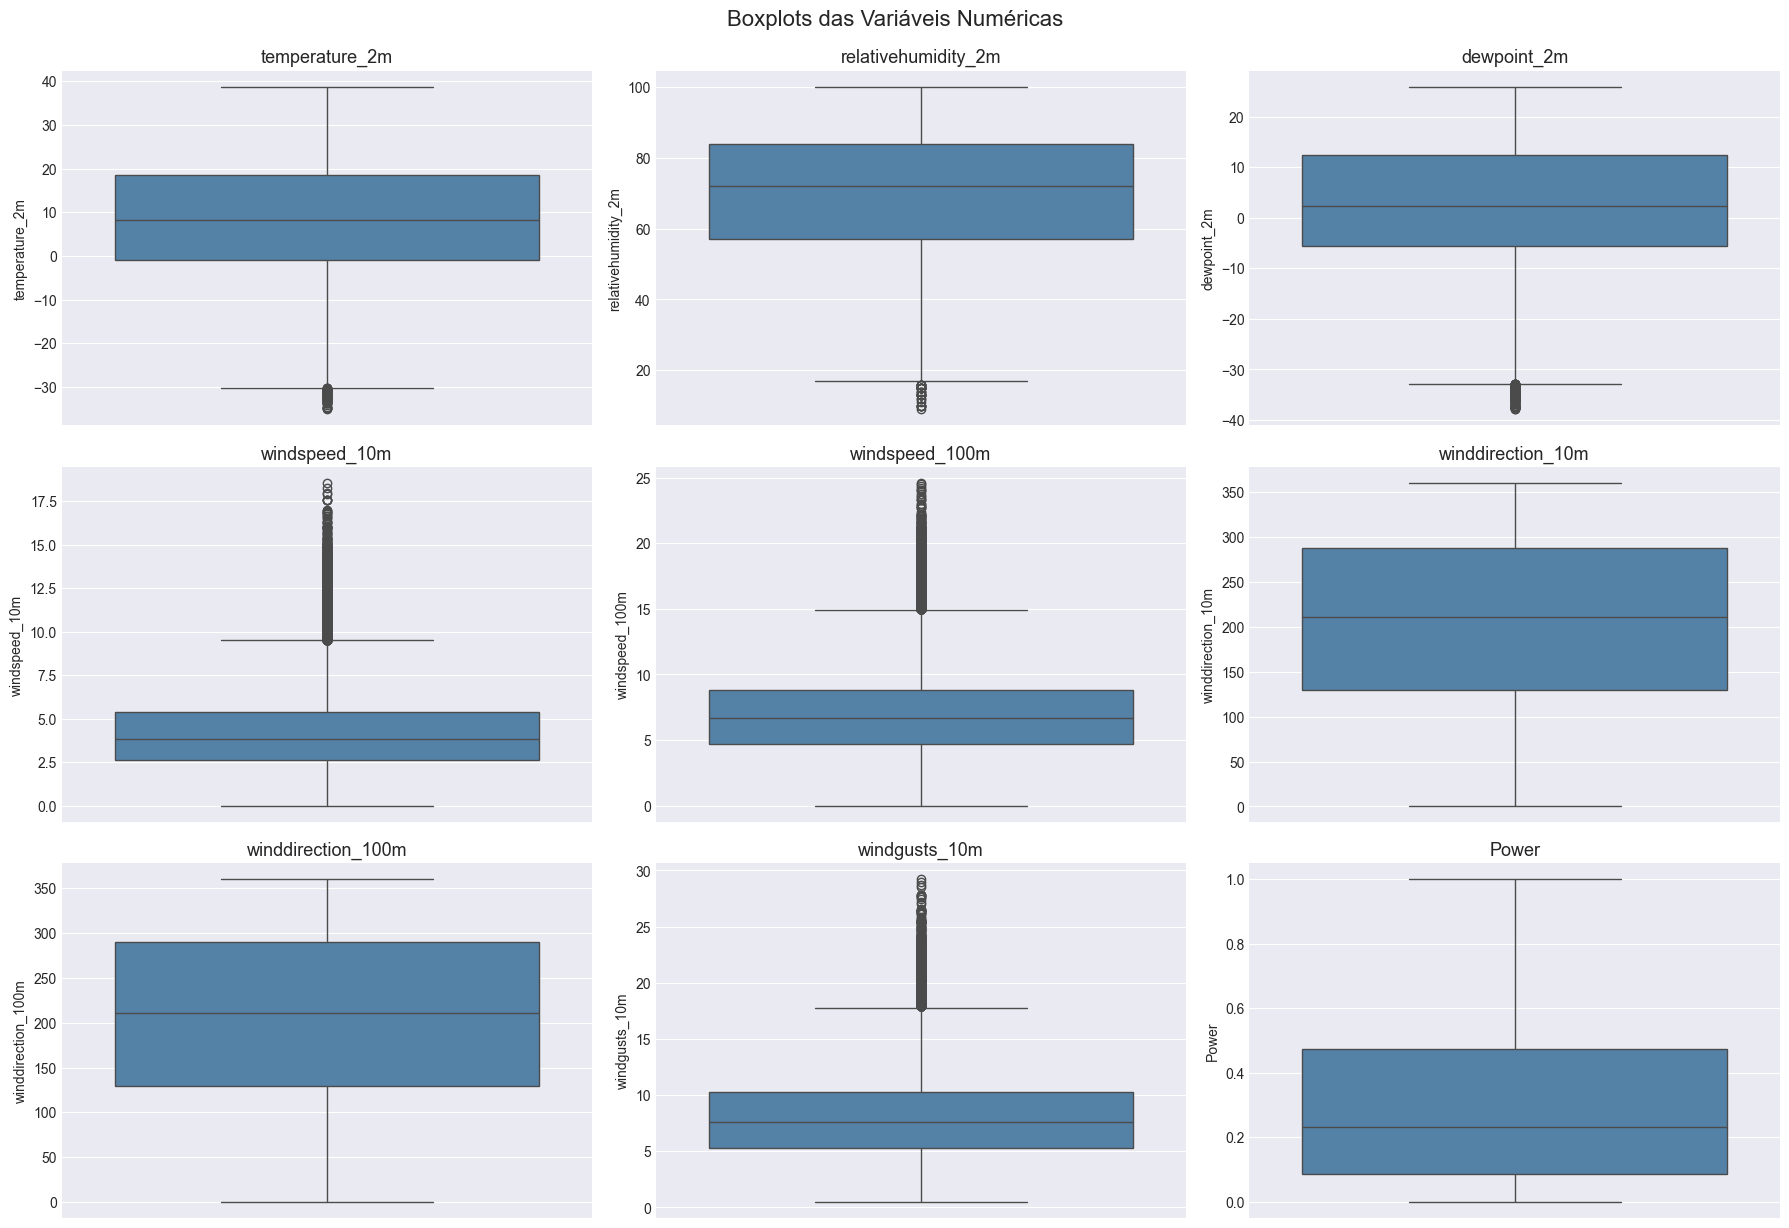

In [7]:
num_cols = ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
            'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
            'winddirection_100m', 'windgusts_10m', 'Power']

n_cols_grid = 3
n_rows_grid = int(np.ceil(len(num_cols) / n_cols_grid))

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, 4 * n_rows_grid))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(y=df[col].dropna(), ax=ax, color='steelblue', orient='v')
    ax.set_title(col, fontsize=13)
    ax.set_ylabel(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Boxplots das Variáveis Numéricas', fontsize=16, y=1.02)
plt.show()


**Informações obtidas:**
- **Outliers visíveis por variável:** Em dados eólicos, outliers em `windgusts_10m` podem representar rajadas extremas reais (relevantes para cargas estruturais). Outliers em `Power` podem indicar registros espúrios ou turbina em modo de teste.
- **Assimetria (skewness):** Se a mediana está deslocada para uma extremidade da caixa, a distribuição é assimétrica — algo comum em velocidade do vento (assimetria positiva, cauda longa à direita).
- **Dispersão comparativa:** Ao visualizar todas as variáveis juntas, é fácil identificar quais possuem maior variabilidade relativa e quais são mais concentradas.
- **Decisões de tratamento:** Outliers extremos podem precisar de tratamento (filtro, winsorização) antes de alimentar modelos preditivos, especialmente se forem erros de sensor.

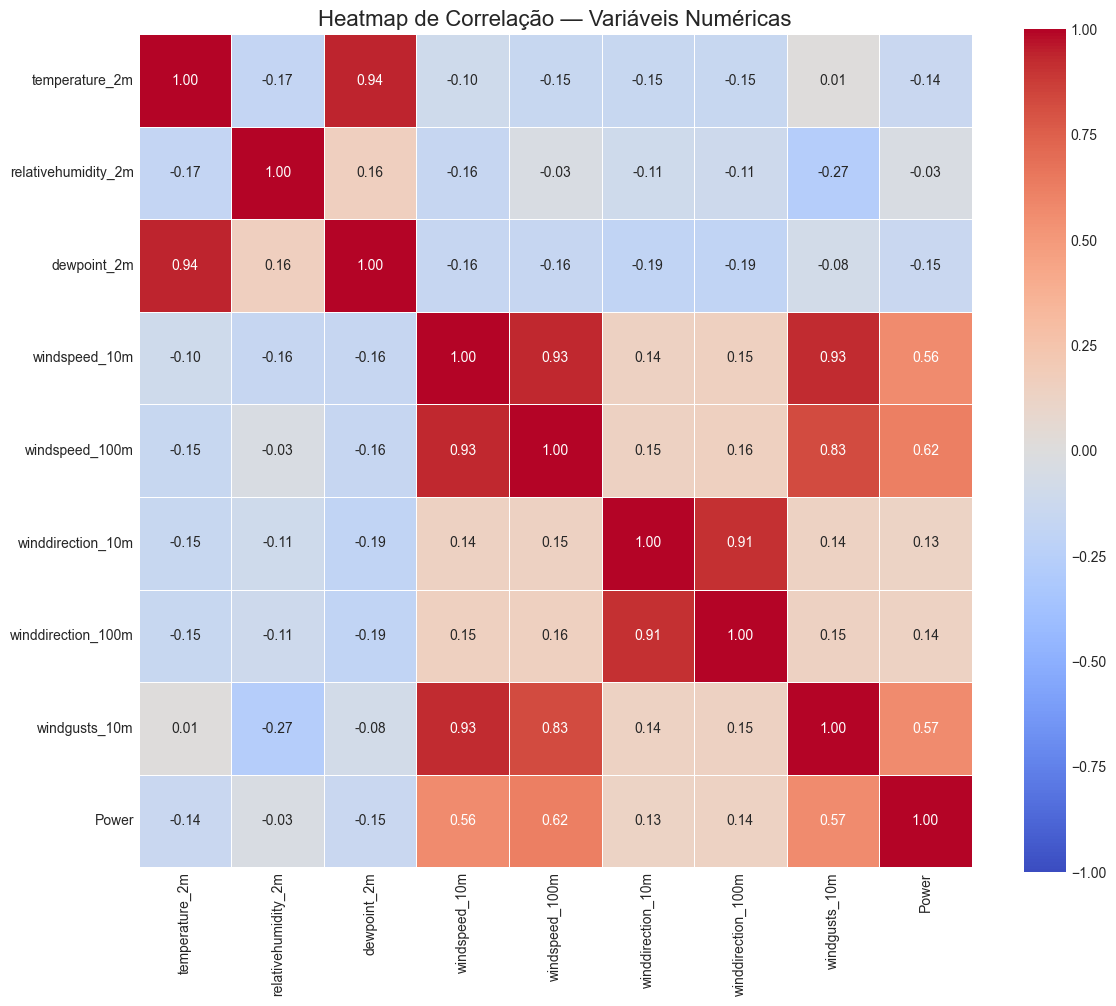


Correlações com Power:
Power                  1.000000
windspeed_100m         0.622108
windgusts_10m          0.568818
windspeed_10m          0.564750
winddirection_100m     0.136620
winddirection_10m      0.128059
relativehumidity_2m   -0.031405
temperature_2m        -0.141187
dewpoint_2m           -0.146789
Name: Power, dtype: float64


In [8]:
num_cols = ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m',
            'windspeed_10m', 'windspeed_100m', 'winddirection_10m',
            'winddirection_100m', 'windgusts_10m', 'Power']

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Heatmap de Correlação — Variáveis Numéricas', fontsize=16)
plt.tight_layout()
plt.show()

print("\nCorrelações com Power:")
print(corr_matrix['Power'].sort_values(ascending=False))


**Informações obtidas:**
- **Correlação com Power:** Identifica quais variáveis são os melhores preditores lineares da potência. Tipicamente, `windspeed_100m` apresenta a maior correlação positiva — confirmando a relação teórica P ∝ v³.
- **Multicolinearidade:** Variáveis altamente correlacionadas entre si (ex: `windspeed_10m` vs `windspeed_100m`, `temperature_2m` vs `dewpoint_2m`) fornecem informação redundante. Para modelos de regressão, incluir ambas pode causar instabilidade nos coeficientes — o heatmap ajuda a decidir quais descartar.
- **Relações meteorológicas:** Permite verificar relações físicas esperadas (ex: temperatura e ponto de orvalho positivamente correlacionados, umidade e temperatura potencialmente anticorrelacionados).
- **Seleção de features:** Variáveis com correlação quase nula com `Power` são candidatas à remoção para simplificar modelos preditivos.

Total: 175200 | Outliers: 4484 (2.6%)



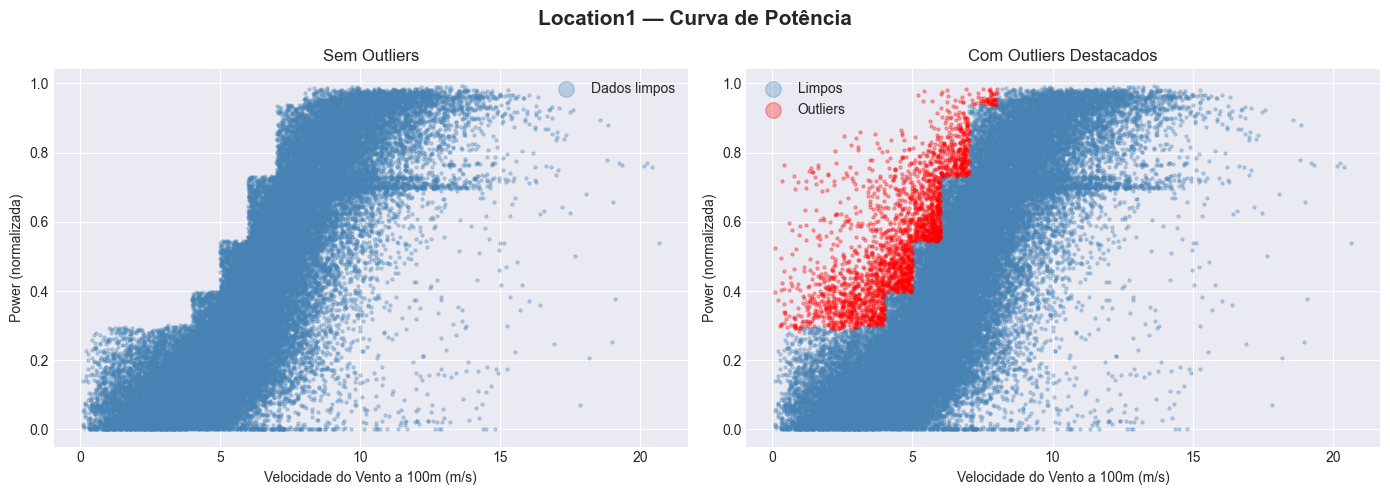

  Location1: 43800 pts | 2445 outliers (5.6%)


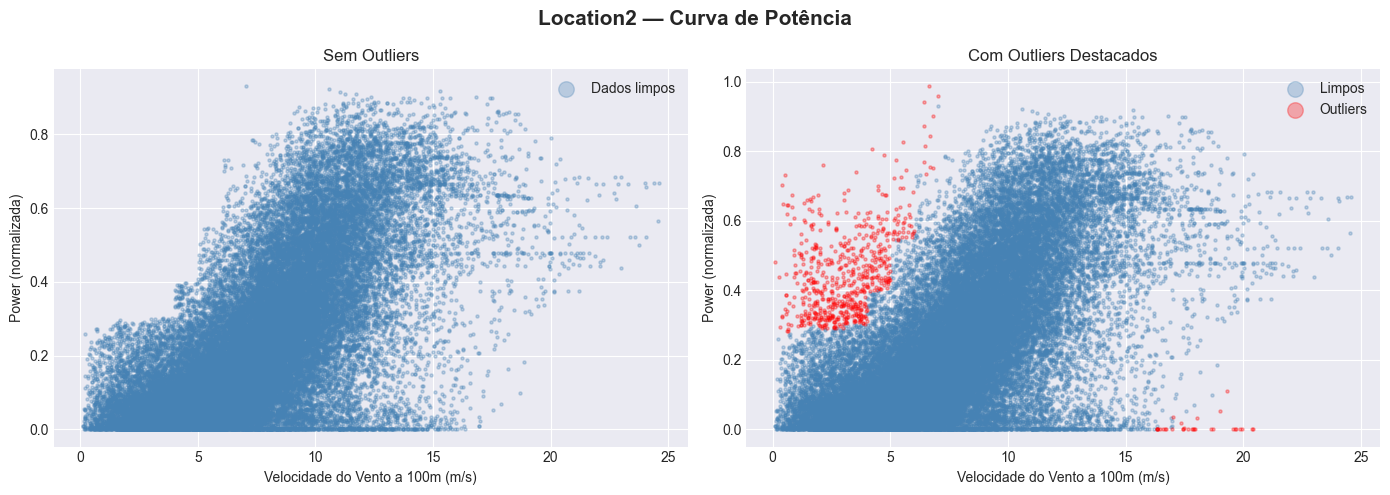

  Location2: 43800 pts | 655 outliers (1.5%)


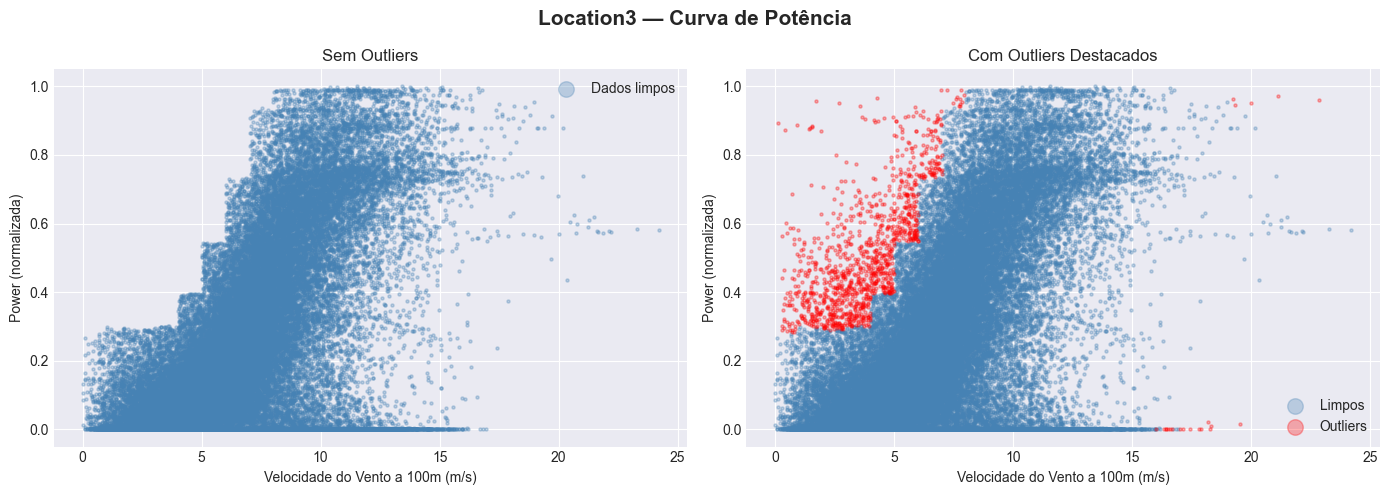

  Location3: 43800 pts | 1185 outliers (2.7%)


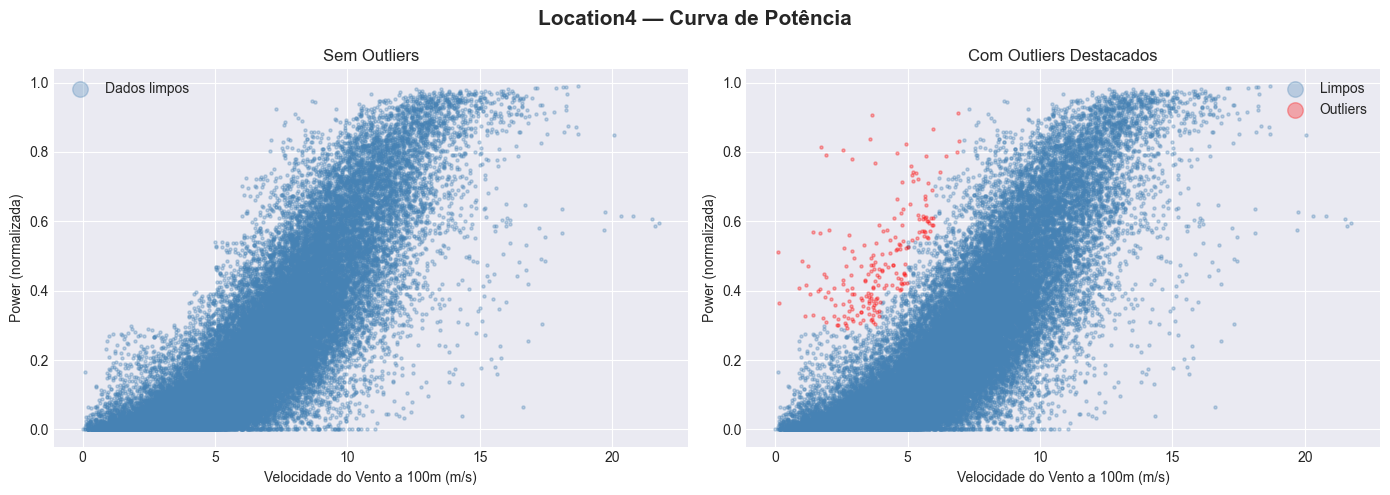

  Location4: 43800 pts | 199 outliers (0.5%)


In [9]:
ws_col = 'windspeed_100m'
pwr_col = 'Power'

# Outlier por IQR dentro de cada bin de 1 m/s de velocidade do vento
df['ws_bin'] = pd.cut(df[ws_col], bins=np.arange(0, df[ws_col].max() + 1, 1))
df['outlier_flag'] = 0
for b, grp in df.groupby('ws_bin', observed=True):
    if len(grp) < 5:
        continue
    q1 = grp[pwr_col].quantile(0.25)
    q3 = grp[pwr_col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (grp[pwr_col] < lower) | (grp[pwr_col] > upper)
    df.loc[mask[mask].index, 'outlier_flag'] = 1

print(f"Total: {len(df)} | Outliers: {df['outlier_flag'].sum()} "
      f"({df['outlier_flag'].mean()*100:.1f}%)\n")

locations = sorted(df['Location'].unique())

for loc in locations:
    df_loc = df[df['Location'] == loc]
    clean = df_loc[df_loc['outlier_flag'] == 0]
    outliers = df_loc[df_loc['outlier_flag'] == 1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{loc} — Curva de Potência', fontsize=15, fontweight='bold')

    ax1.scatter(clean[ws_col], clean[pwr_col],
                alpha=0.3, s=5, c='steelblue', label='Dados limpos')
    ax1.set_title('Sem Outliers')
    ax1.set_xlabel('Velocidade do Vento a 100m (m/s)')
    ax1.set_ylabel('Power (normalizada)')
    ax1.legend(markerscale=5)

    ax2.scatter(clean[ws_col], clean[pwr_col],
                alpha=0.3, s=5, c='steelblue', label='Limpos')
    ax2.scatter(outliers[ws_col], outliers[pwr_col],
                alpha=0.3, s=5, c='red', label='Outliers')
    ax2.set_title('Com Outliers Destacados')
    ax2.set_xlabel('Velocidade do Vento a 100m (m/s)')
    ax2.set_ylabel('Power (normalizada)')
    ax2.legend(markerscale=5)

    plt.tight_layout()
    plt.show()

    n_out = len(outliers)
    pct = n_out / len(df_loc) * 100
    print(f"  {loc}: {len(df_loc)} pts | {n_out} outliers ({pct:.1f}%)")


**Informações obtidas:**
- **Formato sigmoidal esperado:** Sem outliers, a curva deve apresentar três regiões claras: (1) potência zero abaixo do cut-in (~3–4 m/s), (2) crescimento cúbico na zona de operação parcial e (3) platô na potência nominal.
- **Natureza dos outliers:** Os pontos vermelhos no painel direito revelam onde a turbina desviou do comportamento esperado — possíveis causas incluem curtailment, paradas parciais, icing, yaw misalignment ou erros de sensor.
- **Comparação entre localidades:** Diferenças na quantidade de outliers entre localidades podem indicar condições operacionais distintas, maior turbulência, ou problemas de qualidade de dados em locais específicos.
- **Dispersão na zona cúbica:** Alta dispersão na região intermediária sinaliza turbulência elevada ou variações de densidade do ar.
- **Utilidade prática:** Separar dados limpos de outliers é um passo essencial antes de ajustar modelos de curva de potência para estimativa de AEP e detecção de anomalias operacionais.


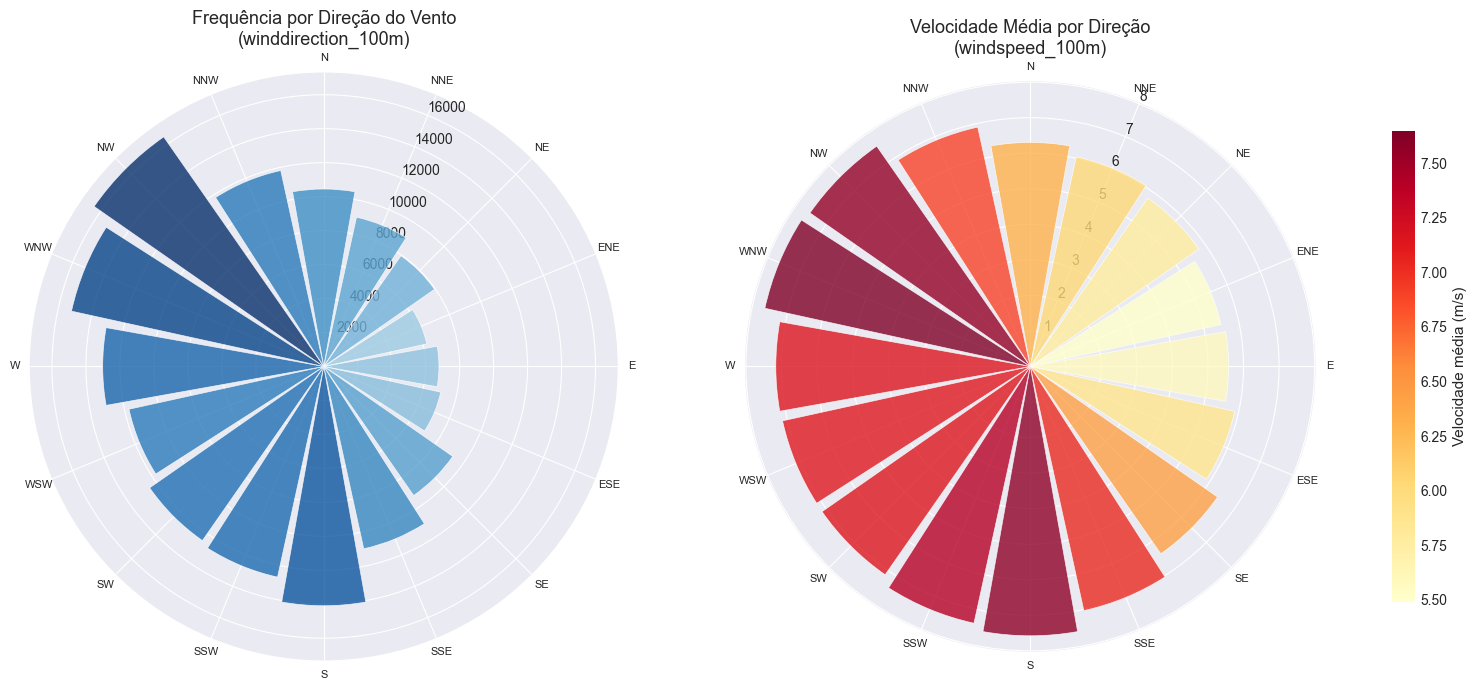

In [10]:
n_sectors = 16
sector_width = 360 / n_sectors  # 22.5° por setor

dir_labels = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
              'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

df['dir_sector'] = df['winddirection_100m'].apply(
    lambda x: int(((x + sector_width / 2) % 360) // sector_width)
)

freq = df.groupby('dir_sector').size().reindex(range(n_sectors), fill_value=0)
mean_speed = df.groupby('dir_sector')['windspeed_100m'].mean().reindex(range(n_sectors), fill_value=0)

angles = np.radians(np.arange(0, 360, sector_width))
bar_width = np.radians(sector_width) * 0.9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={'projection': 'polar'})

bars1 = ax1.bar(angles, freq.values, width=bar_width, alpha=0.8,
                color=plt.cm.Blues(freq.values / freq.values.max()),
                edgecolor='white', linewidth=0.5)
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)
ax1.set_thetagrids(np.arange(0, 360, sector_width), dir_labels, fontsize=8)
ax1.set_title('Frequência por Direção do Vento\n(winddirection_100m)', fontsize=13, pad=20)

norm = plt.Normalize(vmin=mean_speed.values.min(), vmax=mean_speed.values.max())
colors = plt.cm.YlOrRd(norm(mean_speed.values))

bars2 = ax2.bar(angles, mean_speed.values, width=bar_width, alpha=0.8,
                color=colors, edgecolor='white', linewidth=0.5)
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_thetagrids(np.arange(0, 360, sector_width), dir_labels, fontsize=8)
ax2.set_title('Velocidade Média por Direção\n(windspeed_100m)', fontsize=13, pad=20)

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, shrink=0.8, pad=0.1)
cbar.set_label('Velocidade média (m/s)', fontsize=11)

plt.tight_layout()
plt.show()


**Informações obtidas:**
- **Direção predominante do vento:** O setor com a barra mais alta na rosa de frequência indica a direção dominante do regime eólico do local. É a informação mais básica para o projeto de um parque eólico.
- **Direções de maior recurso energético:** A rosa de velocidade média revela de onde vêm os ventos mais intensos. Quando combinada com a frequência, identifica as direções que contribuem mais para a geração total de energia (rosa de energia = frequência × velocidade³).
- **Anisotropia do recurso:** Se a distribuição é fortemente concentrada em 1–2 setores, o site possui um regime eólico bem definido (bom para micrositing). Se for dispersa em muitas direções, há maior complexidade no layout.
- **Aplicação prática:** Esses gráficos guiam decisões como o alinhamento preferencial das fileiras de turbinas, a orientação da nacele de referência e a análise de efeito esteira entre turbinas vizinhas.

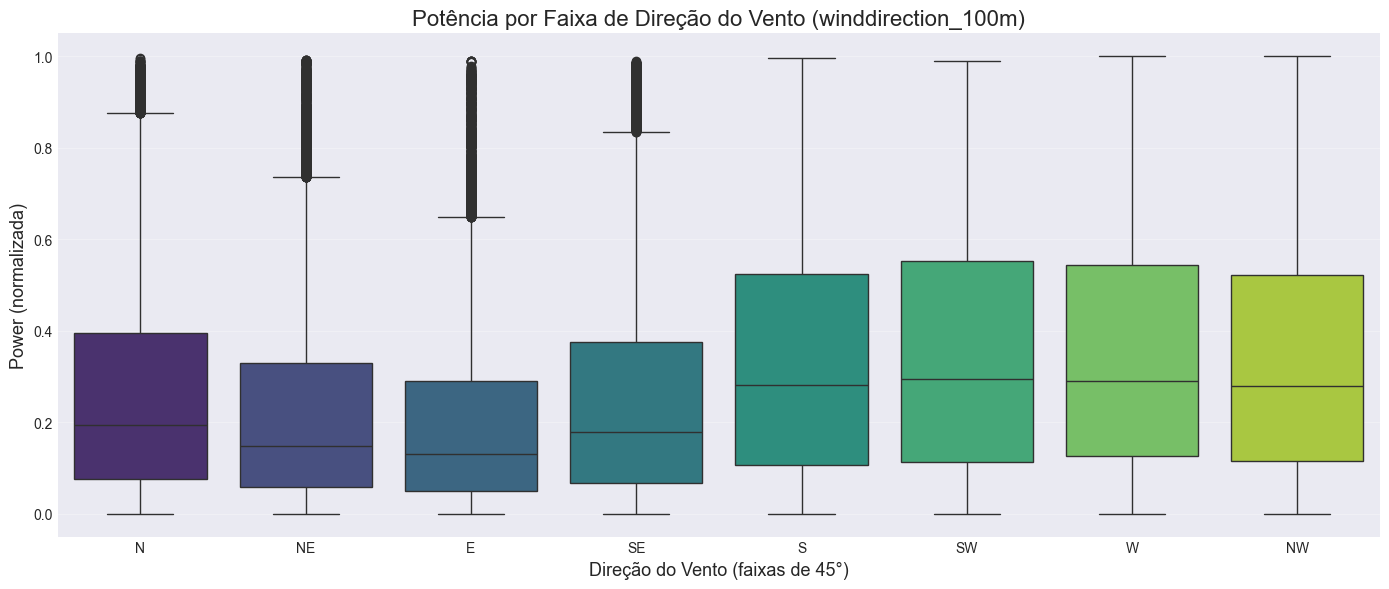

In [11]:

dir_labels_8 = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
bin_edges_8 = [0, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 360]

df['dir_bin'] = pd.cut(
    df['winddirection_100m'],
    bins=bin_edges_8,
    labels=dir_labels_8 + ['N'],  
    include_lowest=True,
    ordered=False
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='dir_bin', y='Power', data=df, ax=ax,
            order=dir_labels_8, palette='viridis')
ax.set_title('Potência por Faixa de Direção do Vento (winddirection_100m)', fontsize=16)
ax.set_xlabel('Direção do Vento (faixas de 45°)', fontsize=13)
ax.set_ylabel('Power (normalizada)', fontsize=13)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Informações obtidas:**
- **Direções mais produtivas:** Faixas com mediana e Q3 mais altos indicam as direções de vento que proporcionam maior geração de energia. Isso reflete não só a frequência, mas a intensidade do vento naquela direção.
- **Variabilidade da geração:** Caixas mais largas (maior intervalo interquartil) indicam alta variabilidade — o vento daquela direção oscila muito em intensidade.
- **Outliers:** Pontos acima dos whiskers podem indicar rajadas esporádicas de alta intensidade; pontos abaixo podem sinalizar períodos de turbina parada ou curtailment.
- **Planejamento de layout:** Em projetos eólicos, saber qual direção entrega mais energia é crucial para o posicionamento otimizado das turbinas (micrositing) e para minimizar efeito esteira (wake effect).

In [12]:
df['wind_dir_sin_10m'] = np.sin(np.radians(df['winddirection_10m']))
df['wind_dir_cos_10m'] = np.cos(np.radians(df['winddirection_10m']))
df['wind_dir_sin_100m'] = np.sin(np.radians(df['winddirection_100m']))
df['wind_dir_cos_100m'] = np.cos(np.radians(df['winddirection_100m']))

df[['winddirection_100m', 'wind_dir_sin_100m', 'wind_dir_cos_100m']].head(10)

,winddirection_100m,wind_dir_sin_100m,wind_dir_cos_100m
0,162,0.309017,-0.951057
1,158,0.374607,-0.927184
2,150,0.500000,-0.866025
3,105,0.965926,-0.258819
4,84,0.994522,0.104528
5,80,0.984808,0.173648
6,78,0.978148,0.207912
7,78,0.978148,0.207912
8,81,0.987688,0.156434
9,86,0.997564,0.069756


### Encoding Circular da Direção do Vento (Seno/Cosseno)

**O que é esta transformação?**
A direção do vento em graus (0°–360°) é uma variável **circular**: 1° e 359° são quase idênticos, mas numericamente distantes. Algoritmos de machine learning interpretariam esses valores como muito diferentes. A decomposição em `sin(θ)` e `cos(θ)` resolve esse problema ao mapear a direção em um espaço contínuo bidimensional onde a circularidade é preservada.

**Informações obtidas e utilidade:**
- **`sin(θ)`** captura a componente **leste–oeste** do vento (positivo = leste, negativo = oeste).
- **`cos(θ)`** captura a componente **norte–sul** (positivo = norte, negativo = sul).
- Juntas, as duas features reconstroem perfeitamente a direção original sem descontinuidades.
- Esta codificação é **essencial** para qualquer modelo preditivo (regressão, redes neurais, etc.) que utilize a direção do vento como feature, pois evita artefatos numéricos causados pela circularidade.

DBSCAN MULTIDIMENSIONAL — POR LOCALIDADE

——————————————————————————————————————————————————
Processando: Location1
  Colunas numéricas válidas: 13
  Features: ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'windspeed_100m', 'winddirection_10m', 'winddirection_100m', 'windgusts_10m', 'Power', 'wind_dir_sin_10m', 'wind_dir_cos_10m', 'wind_dir_sin_100m', 'wind_dir_cos_100m']
  DBSCAN: 4 clusters | 479 pontos de ruído (1.1%)

  Location1 — Resumo dos clusters:
    Ruído: 479 pts | Vento=6.3±5.6 m/s | Power=0.360±0.302
    Cluster 0: 42690 pts | Vento=6.3±2.6 m/s | Power=0.408±0.288
    Cluster 1: 589 pts | Vento=4.3±1.8 m/s | Power=0.234±0.200
    Cluster 2: 27 pts | Vento=12.6±0.9 m/s | Power=0.116±0.123
    Cluster 3: 15 pts | Vento=14.5±0.8 m/s | Power=0.721±0.005

——————————————————————————————————————————————————
Processando: Location2
  Colunas numéricas válidas: 13
  Features: ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'wind

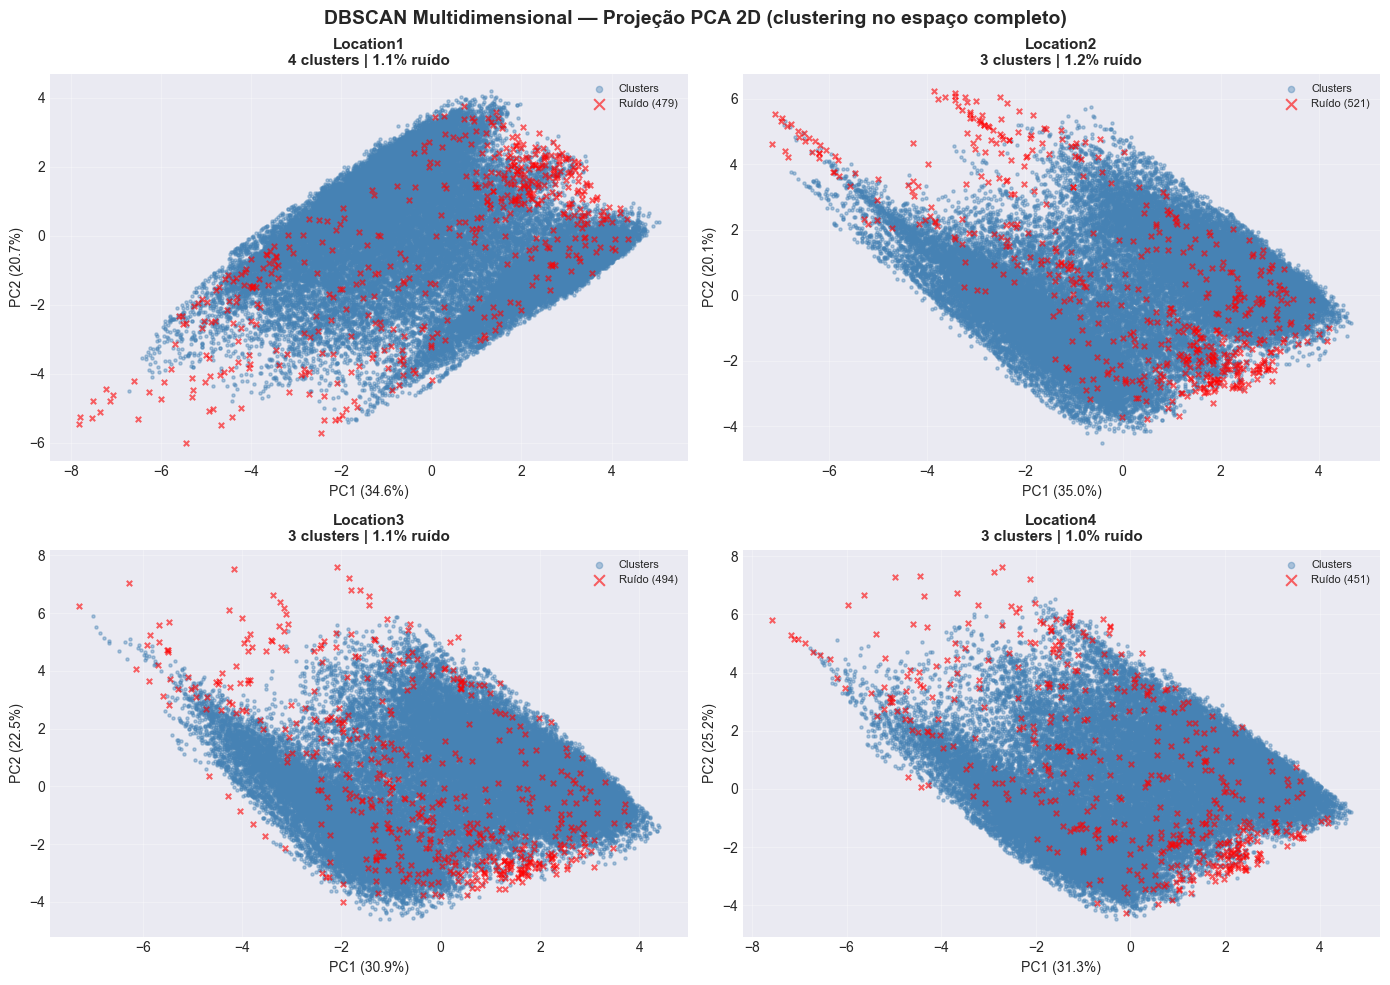

In [13]:
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

print("=" * 70)
print("DBSCAN MULTIDIMENSIONAL — POR LOCALIDADE")
print("=" * 70)

locations = sorted(df['Location'].unique())
n_locs = len(locations)

fig, axes = plt.subplots(2, (n_locs + 1) // 2, figsize=(14, 10))
axes = axes.flatten()

for idx, loc in enumerate(locations):
    df_loc = df[df['Location'] == loc].copy()
    print(f"\n{'—'*50}")
    print(f"Processando: {loc}")

    colunas_num = df_loc.select_dtypes(include=[np.number]).columns.tolist()
    excluir = ['outlier_flag', 'dir_sector', 'dir_bin']
    colunas_num = [c for c in colunas_num if c not in excluir]
    colunas_validas = [c for c in colunas_num if df_loc[c].notna().sum() > 0]
    print(f"  Colunas numéricas válidas: {len(colunas_validas)}")
    print(f"  Features: {colunas_validas}")

    dados = df_loc[colunas_validas].copy()

    imputer = KNNImputer(n_neighbors=3)
    dados_preenchidos = pd.DataFrame(
        imputer.fit_transform(dados), columns=colunas_validas, index=dados.index
    )

    scaler = StandardScaler()
    dados_norm = scaler.fit_transform(dados_preenchidos)

    db = DBSCAN(eps=1.25, min_samples=14)
    labels = db.fit_predict(dados_norm)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    pct_noise = n_noise / len(labels) * 100
    print(f"  DBSCAN: {n_clusters} clusters | {n_noise} pontos de ruído ({pct_noise:.1f}%)")

    # PCA 2D apenas para visualização (clustering feito no espaço completo)
    pca_vis = PCA(n_components=2)
    dados_2d = pca_vis.fit_transform(dados_norm)
    pc1 = dados_2d[:, 0]
    pc2 = dados_2d[:, 1]

    ax = axes[idx]
    mask_noise = (labels == -1)
    mask_clean = ~mask_noise

    if mask_clean.sum() > 0:
        ax.scatter(pc1[mask_clean], pc2[mask_clean],
                   c='steelblue', s=5, alpha=0.4, label='Clusters')
    if mask_noise.sum() > 0:
        ax.scatter(pc1[mask_noise], pc2[mask_noise],
                   c='red', marker='x', s=15, alpha=0.6, label=f'Ruído ({n_noise})')

    ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{loc}\n{n_clusters} clusters | {pct_noise:.1f}% ruído',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, markerscale=2)
    ax.grid(True, alpha=0.3)

    print(f"\n  {loc} — Resumo dos clusters:")
    for cl in sorted(set(labels)):
        cl_mask = (labels == cl)
        cl_data = df_loc[cl_mask]
        label_name = 'Ruído' if cl == -1 else f'Cluster {cl}'
        print(f"    {label_name}: {cl_mask.sum()} pts | "
              f"Vento={cl_data['windspeed_100m'].mean():.1f}±{cl_data['windspeed_100m'].std():.1f} m/s | "
              f"Power={cl_data['Power'].mean():.3f}±{cl_data['Power'].std():.3f}")

for j in range(n_locs, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('DBSCAN Multidimensional — Projeção PCA 2D (clustering no espaço completo)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNÇÕES DE VISUALIZAÇÃO — Reutilizáveis em todo o notebook
# ═══════════════════════════════════════════════════════════════════════════

import plotly.express as px


def run_dbscan_kaggle(df_location, x_col='windspeed_100m', y_col='Power', eps=0.3, min_samples=10):

    labels_series = pd.Series(index=df_location.index, dtype='float64')
    valid = df_location[[x_col, y_col]].dropna()
    if valid.empty:
        return labels_series

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(valid[[x_col, y_col]])

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)

    labels_series.loc[valid.index] = labels
    return labels_series


def plot_power_scatter(df, locations_list, ax=None, cubic_ref=False, sample_size=3000):
    """Scatter velocidade × potência normalizada por localização."""
    speed_col = 'windspeed_100m' if 'windspeed_100m' in df.columns else 'wind_speed_ms'
    power_col = 'Power' if 'Power' in df.columns else 'power_norm'
    loc_col = 'Location' if 'Location' in df.columns else 'turbine'

    if ax is None:
        n = len(locations_list)
        n_cols = 2
        n_rows = int(np.ceil(n / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
        axes = np.atleast_1d(axes).flatten()
    else:
        axes = np.atleast_1d(ax).flatten()
        fig = None

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    v_cubic = np.linspace(0, 20, 200)
    p_cubic = np.clip(v_cubic**3 / (12.0**3), 0, 1)

    for i, loc in enumerate(locations_list):
        axis = axes[i]
        data_loc = df[df[loc_col] == loc][[speed_col, power_col]].dropna()
        if len(data_loc) > sample_size:
            data_loc = data_loc.sample(sample_size, random_state=42)

        color = colors[i % len(colors)]
        axis.scatter(data_loc[speed_col], data_loc[power_col], alpha=0.3, s=8, color=color, label=str(loc))

        if cubic_ref:
            axis.plot(v_cubic, p_cubic, 'k--', linewidth=1.5, label='P ∝ v³ (ref.)')
            axis.set_xlim(0, 22)
            axis.set_ylim(-0.05, 1.1)

        axis.set_xlabel('Velocidade do Vento (m/s)')
        axis.set_ylabel('Potência Normalizada (0–1)')
        axis.set_title(str(loc), fontsize=11)
        axis.legend(fontsize=8)
        axis.grid(alpha=0.3)

    for j in range(len(locations_list), len(axes)):
        if fig is not None:
            fig.delaxes(axes[j])

    if fig is not None:
        title = 'Velocidade × Potência por Localização'
        if cubic_ref:
            title = 'Velocidade × Potência com Curva Teórica Cúbica (P ∝ v³)'
        fig.suptitle(title, fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()


def plot_empirical_curve(df_location, location_name, bins=np.arange(0, 22, 1), ax=None):
    """Curva empírica (média por bin) para uma localização."""
    speed_col = 'windspeed_100m' if 'windspeed_100m' in df_location.columns else 'wind_speed_ms'
    power_col = 'Power' if 'Power' in df_location.columns else 'power_norm'

    df_plot = df_location[[speed_col, power_col]].dropna().copy()
    df_plot['v_bin'] = pd.cut(df_plot[speed_col], bins=bins, labels=bins[:-1])
    emp = df_plot.groupby('v_bin', observed=True)[power_col].agg(['mean', 'std']).reset_index()
    emp['v_bin'] = emp['v_bin'].astype(float)

    created_fig = False
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
        created_fig = True

    ax.plot(emp['v_bin'], emp['mean'], 'o-', linewidth=2, markersize=5, label=str(location_name))
    ax.fill_between(
        emp['v_bin'],
        (emp['mean'] - emp['std']).clip(0),
        (emp['mean'] + emp['std']).clip(0, 1),
        alpha=0.15
    )

    ax.set_xlabel('Velocidade do Vento (m/s)')
    ax.set_ylabel('Potência Normalizada (0–1)')
    ax.set_title(f'Curva Empírica — {location_name}', fontsize=11)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

    if created_fig:
        plt.tight_layout()
        plt.show()


def plot_wind_rose_by_location(df, location_name, ax=None):
    """Rosa dos ventos para uma localização específica."""
    dir_col = 'winddirection_100m' if 'winddirection_100m' in df.columns else 'wind_direction_deg'
    loc_col = 'Location' if 'Location' in df.columns else 'turbine'

    data = df[df[loc_col] == location_name][dir_col].dropna()
    dir_bins = np.arange(0, 361, 45)
    counts, _ = np.histogram(data, bins=dir_bins)
    angles = np.radians(dir_bins[:-1])

    created_fig = False
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
        created_fig = True

    ax.bar(angles, counts, width=np.radians(45), alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(f'Rosa dos Ventos — {location_name}', pad=15, fontsize=11)

    if created_fig:
        plt.tight_layout()
        plt.show()


def plot_aep_heatmap_kaggle(df_location, location_name, k_range, lam_range):
    """Heatmap AEP Weibull normalizado (k × λ) para uma localização."""
    speed_col = 'windspeed_100m' if 'windspeed_100m' in df_location.columns else 'wind_speed_ms'
    power_col = 'Power' if 'Power' in df_location.columns else 'power_norm'

    curve = df_location[[speed_col, power_col]].dropna().sort_values(speed_col)
    curve = curve.groupby(speed_col, as_index=False)[power_col].mean()

    v_data = curve[speed_col].values
    p_data = curve[power_col].values

    def _weibull_pdf(v, k, lam):
        return (k / lam) * (v / lam) ** (k - 1) * np.exp(-(v / lam) ** k)

    def _calc_aep_norm(k, lam):
        v_range = np.arange(0, 30, 0.5)
        p_interp = np.interp(v_range, v_data, p_data, left=0, right=0)
        pdf = _weibull_pdf(v_range, k, lam)
        return np.trapezoid(p_interp * pdf, v_range) * 8760

    rows = []
    for k in k_range:
        for lam in lam_range:
            rows.append({'k': k, 'lam': lam, 'AEP_norm': _calc_aep_norm(k, lam)})

    df_grid = pd.DataFrame(rows)
    heat = df_grid.pivot(index='k', columns='lam', values='AEP_norm')

    fig = px.imshow(
        heat,
        origin='lower',
        aspect='auto',
        color_continuous_scale='YlOrRd',
        labels={
            'x': 'λ (escala Weibull)',
            'y': 'k (forma Weibull)',
            'color': 'AEP normalizado',
        },
        title=f'Heatmap AEP Weibull — {location_name}',
    )
    fig.update_layout(height=520, width=900)
    fig.show()

    return df_grid


print('Funções carregadas: run_dbscan_kaggle, plot_power_scatter, plot_empirical_curve, plot_wind_rose_by_location, plot_aep_heatmap_kaggle')

Funções carregadas: run_dbscan_kaggle, plot_power_scatter, plot_empirical_curve, plot_wind_rose_by_location, plot_aep_heatmap_kaggle


**O que é esta análise?**
O DBSCAN é aplicado sobre **todas as variáveis numéricas** normalizadas de cada localidade — uma abordagem geral que não se restringe à curva de potência. O clustering é executado no espaço completo normalizado (sem PCA), e os resultados são **projetados em PC1 vs PC2** apenas para fins de visualização.

**Pipeline:**
1. **KNNImputer** (k=3): preenchimento temporário de valores faltantes
2. **StandardScaler**: normalização para que todas as variáveis tenham a mesma escala
3. **DBSCAN** (eps=1.5, min_samples=14): clustering no espaço normalizado completo (~13 features)
4. **PCA 2D** (apenas visualização): projeção dos resultados nos dois primeiros componentes principais para plotagem

**Informações obtidas:**
- **Outliers multidimensionais:** Os pontos de ruído (vermelhos, ×) são anomalias que consideram **todas** as variáveis simultaneamente — temperatura, umidade, velocidade/direção do vento, rajadas e potência. Esta abordagem geral detecta padrões anômalos que não seriam visíveis analisando apenas uma relação bivariada.
- **Projeção PC1 vs PC2:** Permite visualizar a separação entre clusters e ruído num espaço 2D que captura a maior variância dos dados. Pontos de ruído distantes dos clusters indicam anomalias em múltiplas variáveis.
- **Comparação entre localidades:** Diferenças no número de clusters e percentual de ruído revelam quais locais possuem dados mais homogêneos e quais apresentam condições atípicas.
- **Parâmetros:** `eps=1.5` e `min_samples=14`. As distâncias euclidianas são calculadas no espaço completo de ~13 features normalizadas.

## Padronização de Colunas — Contrato Canônico


In [15]:
# ── Padronização de colunas — Contrato Canônico (better_graphs.md) ─────────
CANONICAL_RENAME = {
    "windspeed_100m": "wind_speed_ms",
    "Power": "power_norm",
    "Location": "turbine",
    "Time": "timestamp",
    "winddirection_100m": "wind_direction_deg",
}

# Renomear apenas colunas que existem no dataframe
df_canonical = df.rename(columns={k: v for k, v in CANONICAL_RENAME.items() if k in df.columns})
print("Colunas canônicas disponíveis:", [c for c in df_canonical.columns if c in CANONICAL_RENAME.values()])
print(df_canonical.head(2))


Colunas canônicas disponíveis: ['timestamp', 'wind_speed_ms', 'wind_direction_deg', 'power_norm', 'turbine']
             timestamp  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0  2017-01-02 00:00:00       -1.944444                   85    -4.166667   
1  2017-01-02 01:00:00       -2.000000                   86    -4.055556   

   windspeed_10m  wind_speed_ms  winddirection_10m  wind_direction_deg  \
0           1.44           1.26                146                 162   
1           2.06           3.99                151                 158   

   windgusts_10m  power_norm    turbine      ws_bin  outlier_flag  dir_sector  \
0            1.4      0.1635  Location1  (1.0, 2.0]             0           7   
1            4.4      0.1424  Location1  (3.0, 4.0]             0           7   

  dir_bin  wind_dir_sin_10m  wind_dir_cos_10m  wind_dir_sin_100m  \
0       S          0.559193         -0.829038           0.309017   
1       S          0.484810         -0.874620           0.3

## Gráficos Melhorados e Novos

### Rosa dos Ventos


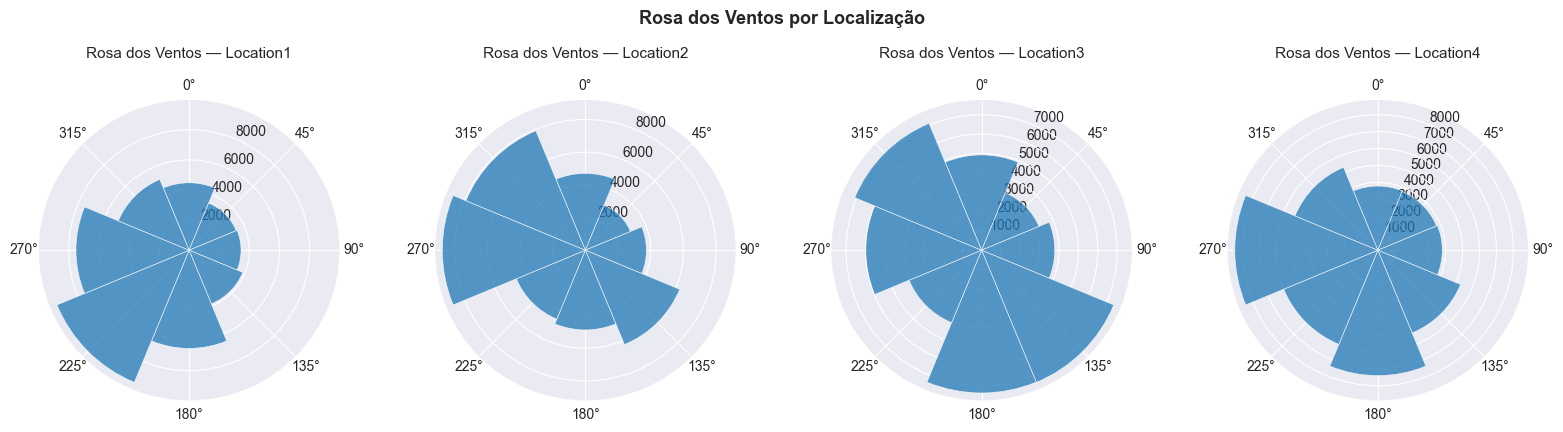

Rosa dos ventos salva em kaggle_wind_rose.png


In [16]:
import matplotlib.pyplot as plt

# ── Rosa dos Ventos por Localização ──────────────────────────────────────────
loc_col = 'Location' if 'Location' in df.columns else 'turbine'
locations = sorted(df[loc_col].unique())

fig, axes = plt.subplots(1, len(locations), subplot_kw={'projection': 'polar'},
                         figsize=(4 * len(locations), 4))
if len(locations) == 1:
    axes = [axes]

for ax, loc in zip(axes, locations):
    plot_wind_rose_by_location(df, loc, ax=ax)

fig.suptitle('Rosa dos Ventos por Localização', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('kaggle_wind_rose.png', dpi=120, bbox_inches='tight')
plt.show()
print('Rosa dos ventos salva em kaggle_wind_rose.png')

### Histogramas de Velocidade com Ajuste Weibull


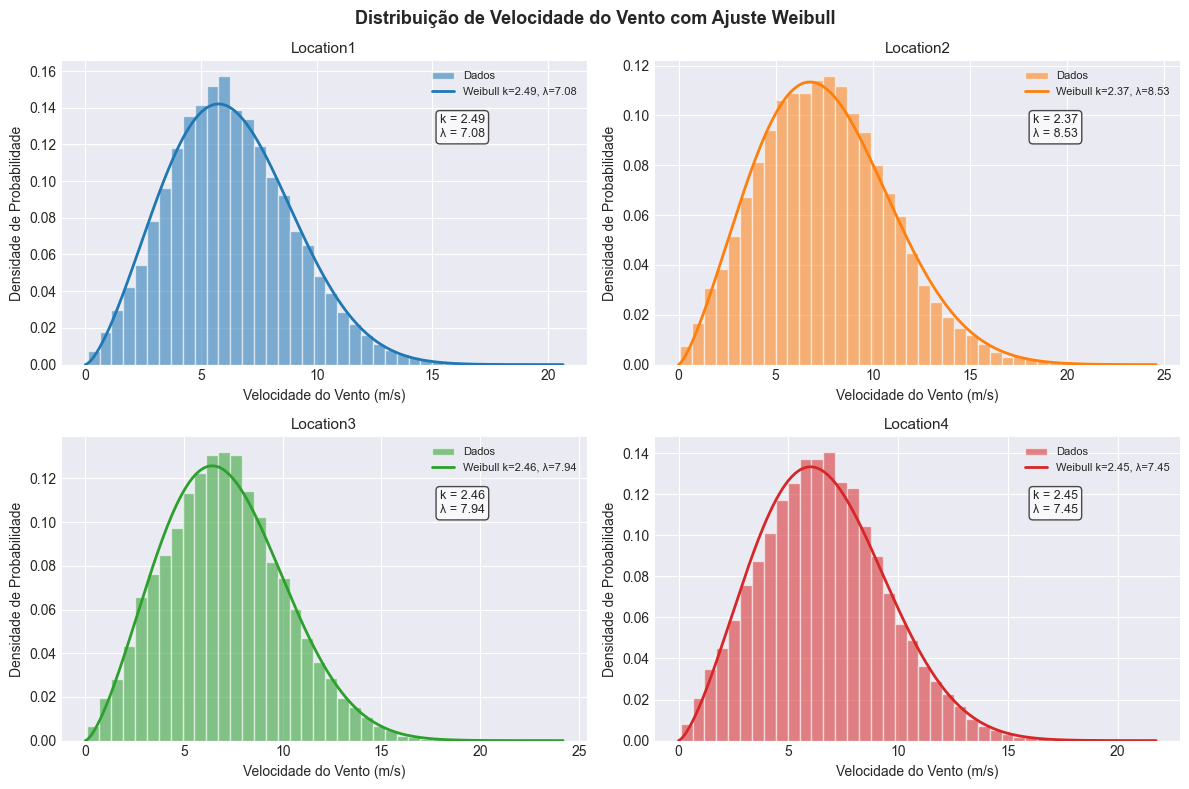

Histogramas Weibull salvos em kaggle_weibull_histograms.png


In [17]:
from scipy.stats import weibull_min
import matplotlib.pyplot as plt
import numpy as np

# ── Histogramas de Velocidade com Ajuste Weibull ─────────────────────────────
speed_col = "windspeed_100m" if "windspeed_100m" in df.columns else "wind_speed_ms"
loc_col = "Location" if "Location" in df.columns else "turbine"

locations = sorted(df[loc_col].unique())
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, loc, color in zip(axes, locations, colors):
    speeds = df[df[loc_col] == loc][speed_col].dropna()
    speeds = speeds[speeds > 0]

    # Ajuste Weibull
    try:
        c, loc_param, scale = weibull_min.fit(speeds, floc=0)
    except Exception:
        c, scale = 2.0, 7.0

    # Histograma
    ax.hist(speeds, bins=40, density=True, alpha=0.55, color=color, edgecolor="white", label="Dados")

    # PDF Weibull ajustada
    v_range = np.linspace(0, speeds.max(), 300)
    pdf = weibull_min.pdf(v_range, c, loc=0, scale=scale)
    ax.plot(v_range, pdf, color=color, linewidth=2, label=f"Weibull k={c:.2f}, λ={scale:.2f}")

    ax.set_title(str(loc), fontsize=11)
    ax.set_xlabel("Velocidade do Vento (m/s)")
    ax.set_ylabel("Densidade de Probabilidade")
    ax.legend(fontsize=8)
    ax.annotate(f"k = {c:.2f}\nλ = {scale:.2f}", xy=(0.72, 0.75), xycoords="axes fraction",
                fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

fig.suptitle("Distribuição de Velocidade do Vento com Ajuste Weibull", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("kaggle_weibull_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Histogramas Weibull salvos em kaggle_weibull_histograms.png")


### Scatter Velocidade × Potência com Referência Cúbica


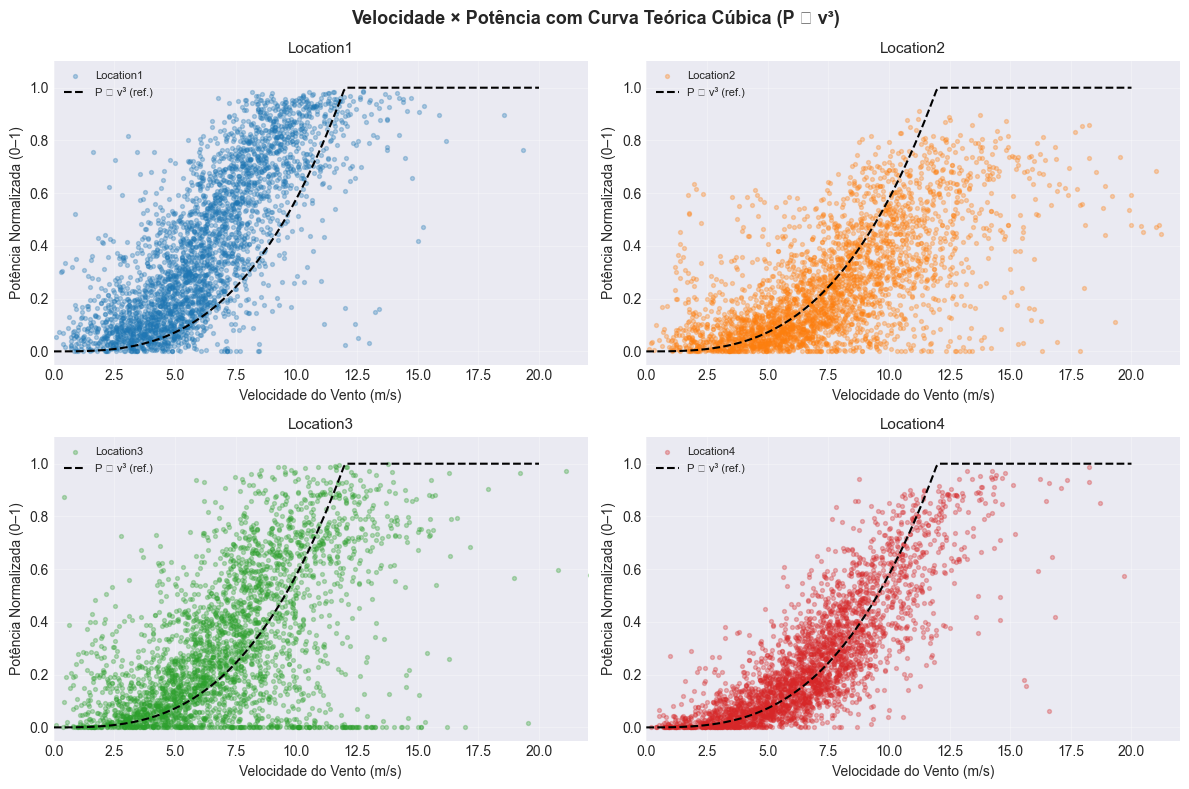

In [18]:
# ── Scatter Velocidade × Potência com Curva Teórica Cúbica ────────────────────
loc_col = 'Location' if 'Location' in df.columns else 'turbine'
locations = sorted(df[loc_col].unique())

plot_power_scatter(df, locations, cubic_ref=True, sample_size=3000)

### Heatmap de Correlação com Anotações


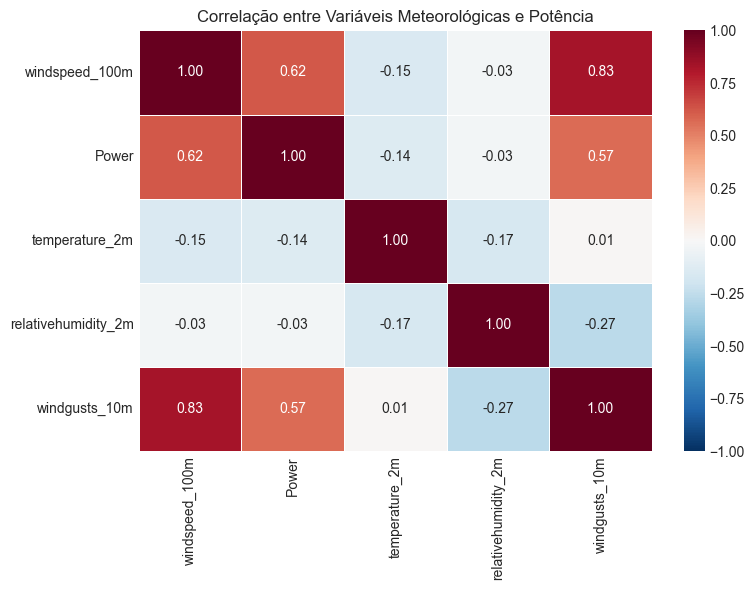

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Heatmap de Correlação com Anotações ──────────────────────────────────────
num_cols = ["windspeed_100m", "Power", "temperature_2m", "relativehumidity_2m", "windgusts_10m"]
available_cols = [c for c in num_cols if c in df.columns]

if len(available_cols) >= 2:
    corr = df[available_cols].corr().round(2)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, ax=ax,
                annot_kws={"size": 10},
                linewidths=0.5)
    ax.set_title("Correlação entre Variáveis Meteorológicas e Potência", fontsize=12)
    plt.tight_layout()
    plt.savefig("kaggle_correlation_heatmap.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("Colunas insuficientes para heatmap:", available_cols)


### Box Plot de Potência por Localização


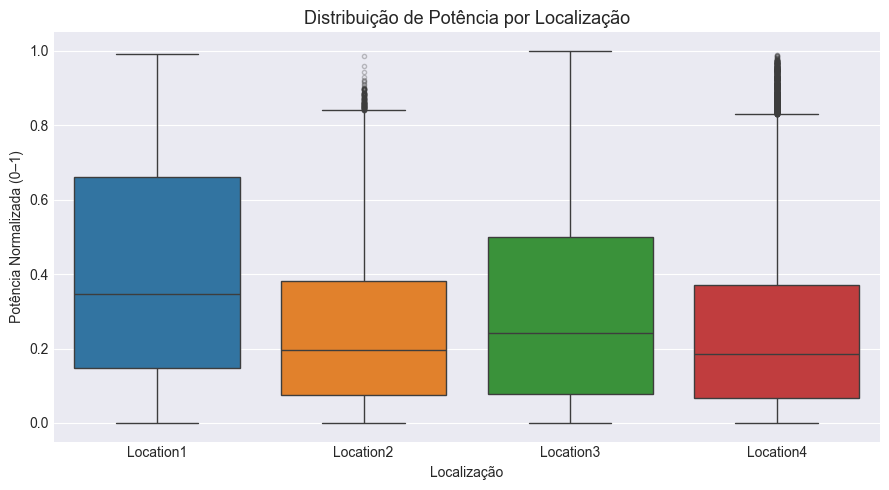

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# ── Box Plot de Potência por Localização ─────────────────────────────────────
power_col = "Power" if "Power" in df.columns else "power_norm"
loc_col = "Location" if "Location" in df.columns else "turbine"

fig, ax = plt.subplots(figsize=(9, 5))
palette = {"Location1": "#1f77b4", "Location2": "#ff7f0e", "Location3": "#2ca02c", "Location4": "#d62728"}
sns.boxplot(data=df, x=loc_col, y=power_col, palette=palette, ax=ax, flierprops={"marker": ".", "alpha": 0.3})
ax.set_xlabel("Localização")
ax.set_ylabel("Potência Normalizada (0–1)")
ax.set_title("Distribuição de Potência por Localização", fontsize=13)
plt.tight_layout()
plt.savefig("kaggle_boxplot_power.png", dpi=120, bbox_inches="tight")
plt.show()


### Scatter Velocidade × Potência Colorido por Temperatura


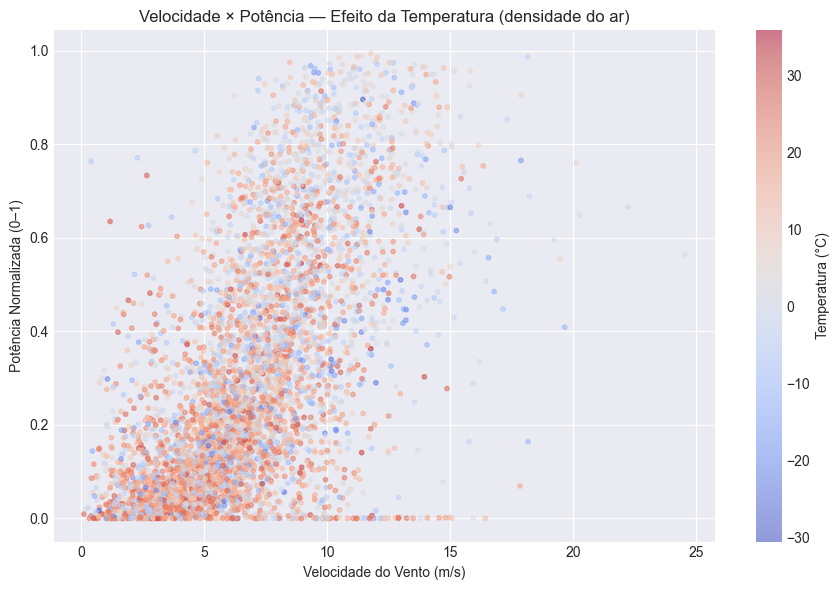

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ── Scatter Velocidade × Potência Colorido por Temperatura ────────────────────
speed_col = "windspeed_100m" if "windspeed_100m" in df.columns else "wind_speed_ms"
power_col = "Power" if "Power" in df.columns else "power_norm"
temp_col = "temperature_2m"  # já convertida para °C se disponível

if temp_col in df.columns:
    sample = df[[speed_col, power_col, temp_col]].dropna().sample(min(5000, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(9, 6))
    sc = ax.scatter(sample[speed_col], sample[power_col], c=sample[temp_col],
                    cmap="coolwarm", alpha=0.5, s=10)
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Temperatura (°C)")
    ax.set_xlabel("Velocidade do Vento (m/s)")
    ax.set_ylabel("Potência Normalizada (0–1)")
    ax.set_title("Velocidade × Potência — Efeito da Temperatura (densidade do ar)", fontsize=12)
    plt.tight_layout()
    plt.savefig("kaggle_scatter_temperature.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print(f"Coluna '{temp_col}' não encontrada. Verifique o nome da coluna de temperatura.")


### Curva de Potência Empírica por Localização


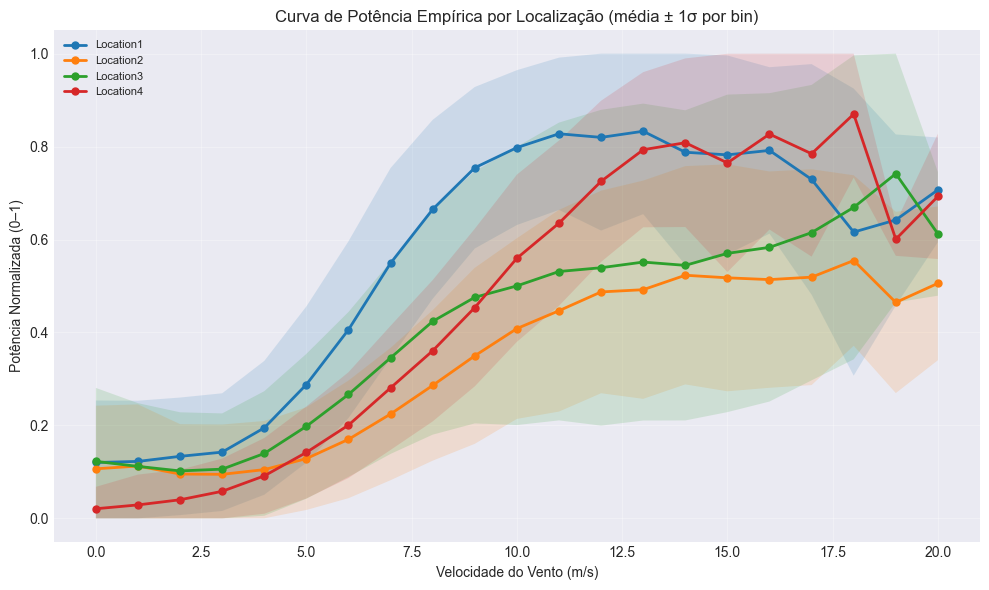

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# ── Curva de Potência Empírica por Localização (média por bin) ─────────────────
loc_col = 'Location' if 'Location' in df.columns else 'turbine'
locations = sorted(df[loc_col].unique())
bins = np.arange(0, 22, 1)

fig, ax = plt.subplots(figsize=(10, 6))
for loc in locations:
    df_loc = df[df[loc_col] == loc].copy()
    plot_empirical_curve(df_loc, loc, bins=bins, ax=ax)

ax.set_title('Curva de Potência Empírica por Localização (média ± 1σ por bin)', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kaggle_empirical_power_curve.png', dpi=120, bbox_inches='tight')
plt.show()

### Série Temporal Mensal de Potência


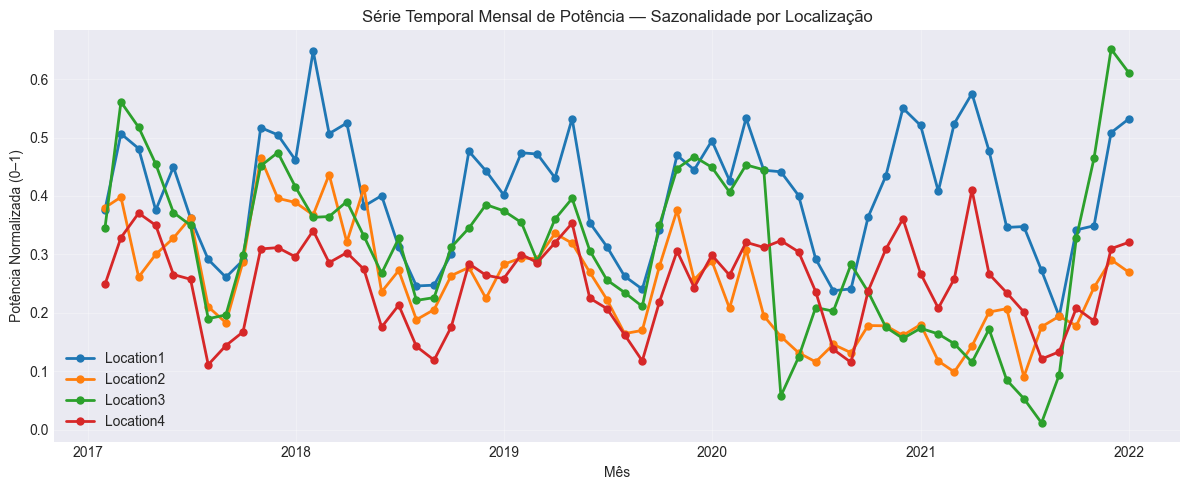

In [23]:
import matplotlib.pyplot as plt

# ── Série Temporal Mensal de Potência por Localização ─────────────────────────
power_col = "Power" if "Power" in df.columns else "power_norm"
loc_col = "Location" if "Location" in df.columns else "turbine"
time_col = "Time" if "Time" in df.columns else "timestamp"

if time_col in df.columns:
    df_ts = df.copy()
    df_ts[time_col] = pd.to_datetime(df_ts[time_col], errors="coerce")
    df_ts = df_ts.set_index(time_col)

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = {"Location1": "#1f77b4", "Location2": "#ff7f0e", "Location3": "#2ca02c", "Location4": "#d62728"}
    for loc in sorted(df_ts[loc_col].unique()):
        monthly = df_ts[df_ts[loc_col] == loc][power_col].resample("ME").mean()
        ax.plot(monthly.index, monthly.values, "o-", linewidth=2, markersize=5,
                color=colors.get(str(loc), None), label=str(loc))

    ax.set_xlabel("Mês")
    ax.set_ylabel("Potência Normalizada (0–1)")
    ax.set_title("Série Temporal Mensal de Potência — Sazonalidade por Localização", fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("kaggle_monthly_timeseries.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print(f"Coluna de tempo '{time_col}' não encontrada.")
